# Stock Market Prediction System
## Random Forest, XGBoost & SVM with Technical Indicators

**Three classifiers trained on 30+ technical features to predict next-day stock price direction.**

Pipeline:
1. Data Collection & Preprocessing
2. Feature Engineering (30+ indicators)
3. Random Forest — ensemble with calibrated probabilities
4. XGBoost — gradient boosting with strong regularisation
5. SVM — RBF kernel with feature scaling
6. Three-model comparison with ROC curves
7. Walk-forward backtesting (10-fold time-series CV)

## Setup and Imports

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

import config
from config import print_config

from src.data_collection import download_stock_data, download_multiple_stocks, load_stock_data
from src.preprocessing import preprocess_stock_data
from src.feature_engineering import engineer_all_features, prepare_ml_data
from src.models import (
    split_train_test,
    train_random_forest, evaluate_model,
    train_svm, evaluate_svm,
    plot_confusion_matrix, plot_feature_importance,
)
from src.xgboost_model import (
    train_xgboost, evaluate_xgboost_model,
    plot_xgb_confusion_matrix, plot_xgb_feature_importance,
)
from src.backtesting import walk_forward_validation, plot_backtest_results
from comparison.compare_models import run_full_comparison
from main import run_complete_pipeline, run_multiple_stocks

print('All imports successful!')

All imports successful!


## Configuration

Central settings live in `config.py`. Edit that file to change tickers, date range, or model hyperparameters.

In [2]:
config.print_config()

STOCK PREDICTION PROJECT CONFIGURATION
Tickers: AAPL, MSFT, GOOGL, AMZN, TSLA
Date Range: 2021-04-29 to 2026-04-28
Rolling Windows: [5, 10, 20]
Volatility Window: 20 days
Momentum Window: 5 days
Prediction Horizon: 1 day(s)
Test Size: 20.0%
Random Forest Estimators: 300
Max Depth: 4
Min Samples Split: 30
Min Samples Leaf: 15
Backtesting Splits: 10
Verbose Logging: True


## Step 1: Data Pipeline

Download 5 years of OHLCV data from Yahoo Finance, clean it, and engineer 30+ technical indicators.

Indicators include: RSI, MACD (normalised), Bollinger Band width/position, ATR (normalised), OBV change, SMAs, momentum windows, lagged returns, volume ratio, and a price-based sentiment proxy.

In [3]:
TICKER = 'AAPL'

# Load existing data or download fresh
raw_data = load_stock_data(TICKER, 'raw')
if raw_data is None:
    print(f'Downloading {TICKER} from Yahoo Finance...')
    raw_data = download_stock_data(TICKER, config.START_DATE, config.END_DATE, save=True)

print(f'Raw data shape: {raw_data.shape}')
print(raw_data.tail(3))

# Preprocess: drop unnecessary columns, forward-fill gaps, validate
processed_data = preprocess_stock_data(raw_data)
print(f'\nProcessed data shape: {processed_data.shape}')

# Feature engineering: 30+ technical indicators
feature_data = engineer_all_features(processed_data)
feature_data.to_csv(config.get_data_path(TICKER, 'features'), index=False)

# Prepare ML arrays (drops NaN rows from rolling window warmup)
X, y, feature_names = prepare_ml_data(feature_data)
print(f'\nML dataset: {X.shape[0]} samples x {X.shape[1]} features')
print(f'Target balance (0=down, 1=up): {y.value_counts().to_dict()}')
print(f'\nAll features ({len(feature_names)}):')
for f in feature_names:
    print(f'  {f}')

✅ Loaded 1587 rows from d:\machine learning\Machine Learning Project\stock_ml_project\data\raw\AAPL_raw.csv
Raw data shape: (1587, 7)
           Date       Close        High         Low        Open    Volume  \
1584 2026-04-23  273.429993  275.769989  271.649994  275.049988  33399600   
1585 2026-04-24  271.059998  273.059998  269.649994  272.760010  38157100   
1586 2026-04-27  267.609985  268.359985  265.070007  266.089996  41407600   

     Ticker  
1584   AAPL  
1585   AAPL  
1586   AAPL  

PREPROCESSING PIPELINE

Step 1: Cleaning data...

Step 2: Handling missing values...
Dropped 0 rows with missing values

Step 3: Validating data...
✅ Data validation passed

Preprocessing complete: 1587 rows


Processed data shape: (1587, 7)

FEATURE ENGINEERING PIPELINE

✅ Added 'Returns' feature
✅ Added 'SMA_5' feature
✅ Added 'SMA_10' feature
✅ Added 'SMA_20' feature
✅ Added 'Volatility' feature (window=20)
✅ Added 'Momentum_3' feature
✅ Added 'Momentum_5' feature
✅ Added 'Momentum_10' featur

## Step 2: Chronological Train/Test Split

We split **chronologically** — never randomly — to avoid look-ahead bias.  
The last 20% of rows form the held-out test set; the model never sees future data during training.

In [4]:
X_train, X_test, y_train, y_test = split_train_test(X, y)

Train set: 1252 samples
Test set: 314 samples
Train period: index 20 to 1271
Test period: index 1272 to 1585


## Step 3: Random Forest

Plain Random Forest without `class_weight='balanced'` — the 53/47 class imbalance is mild enough that balanced weighting only compresses predicted probabilities and hurts threshold reliability.

Key hyperparameters (`config.RF_PARAMS`): `n_estimators=300`, `max_depth=4`, `min_samples_leaf=15`.


TRAINING RANDOM FOREST MODEL
Parameters: {'n_estimators': 300, 'max_depth': 4, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'random_state': 42, 'n_jobs': 1}
✅ Model training complete!

MODEL EVALUATION

TRAINING SET PERFORMANCE:
  Accuracy:  0.6494
  Precision: 0.6087
  Recall:    0.9488
  F1 Score:  0.7416

TEST SET PERFORMANCE:
  Accuracy:  0.5382
  Precision: 0.5382
  Recall:    0.8545
  F1 Score:  0.6604

⚠️  Warning: Possible overfitting detected!
   Train accuracy is 11.11% higher than test

DETAILED CLASSIFICATION REPORT (Test Set):
              precision    recall  f1-score   support

    Down (0)       0.54      0.19      0.28       149
      Up (1)       0.54      0.85      0.66       165

    accuracy                           0.54       314
   macro avg       0.54      0.52      0.47       314
weighted avg       0.54      0.54      0.48       314



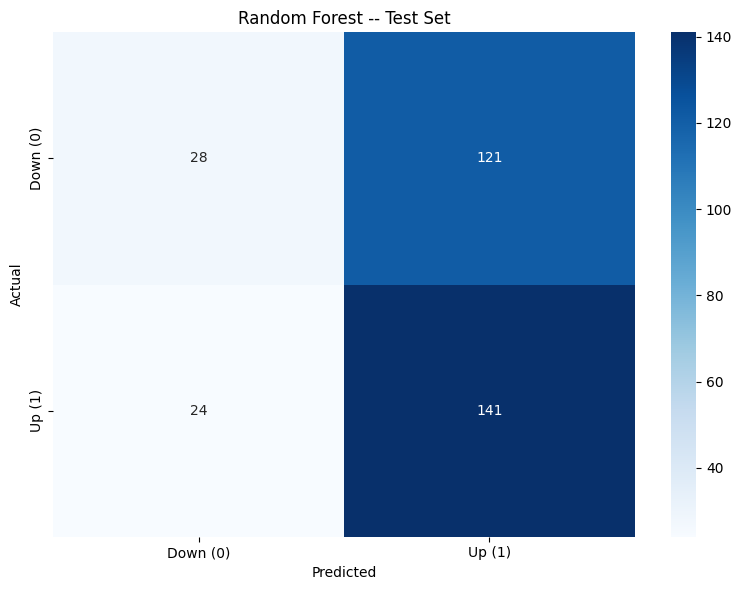


Confusion Matrix Breakdown:
  True Negatives (predicted down, was down):  28
  False Positives (predicted up, was down):   121
  False Negatives (predicted down, was up):   24
  True Positives (predicted up, was up):      141


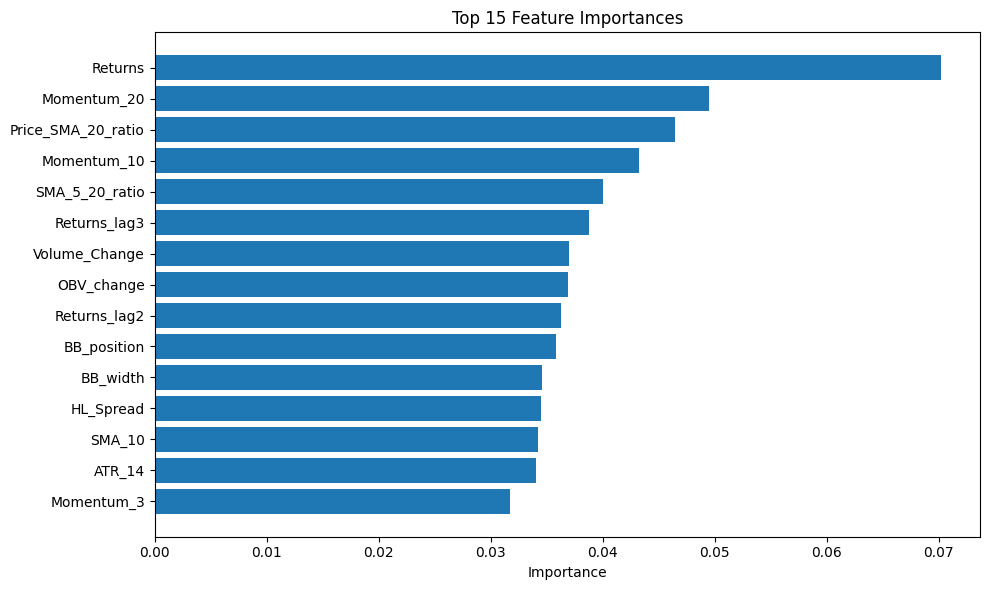


Top 15 Features:
  Returns: 0.0702
  Momentum_20: 0.0495
  Price_SMA_20_ratio: 0.0465
  Momentum_10: 0.0432
  SMA_5_20_ratio: 0.0400
  Returns_lag3: 0.0387
  Volume_Change: 0.0370
  OBV_change: 0.0369
  Returns_lag2: 0.0363
  BB_position: 0.0358
  BB_width: 0.0346
  HL_Spread: 0.0345
  SMA_10: 0.0342
  ATR_14: 0.0341
  Momentum_3: 0.0318


In [5]:
rf_model = train_random_forest(X_train, y_train)
rf_metrics = evaluate_model(rf_model, X_train, y_train, X_test, y_test)

rf_pred = rf_model.predict(X_test)
plot_confusion_matrix(y_test, rf_pred, title='Random Forest -- Test Set')
plot_feature_importance(rf_model, feature_names, top_n=15)

## Step 4: XGBoost

Gradient boosting with strong regularisation to prevent memorisation on ~1 250 training samples.

Key hyperparameters (`config.XGB_PARAMS`): `max_depth=3`, `min_child_weight=10`, `reg_lambda=3.0`, `learning_rate=0.05`.


TRAINING XGBOOST MODEL
Parameters: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_weight': 10, 'gamma': 0.2, 'reg_alpha': 0.5, 'reg_lambda': 3.0, 'scale_pos_weight': 1, 'eval_metric': 'logloss', 'random_state': 42}

Training model...
✅ Model training complete!

XGBOOST MODEL EVALUATION

CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

    Down (0)       0.58      0.30      0.40       149
      Up (1)       0.56      0.81      0.66       165

    accuracy                           0.57       314
   macro avg       0.57      0.55      0.53       314
weighted avg       0.57      0.57      0.54       314


TRAINING SET PERFORMANCE:
  Accuracy:  0.8155
  Precision: 0.7883
  Recall:    0.8916
  F1 Score:  0.8367
  ROC-AUC:   0.8988

TEST SET PERFORMANCE:
  Accuracy:  0.5669
  Precision: 0.5612
  Recall:    0.8061
  F1 Score:  0.6617
  ROC-AUC:   0.5707

⚠️  Warning: Possible overfittin

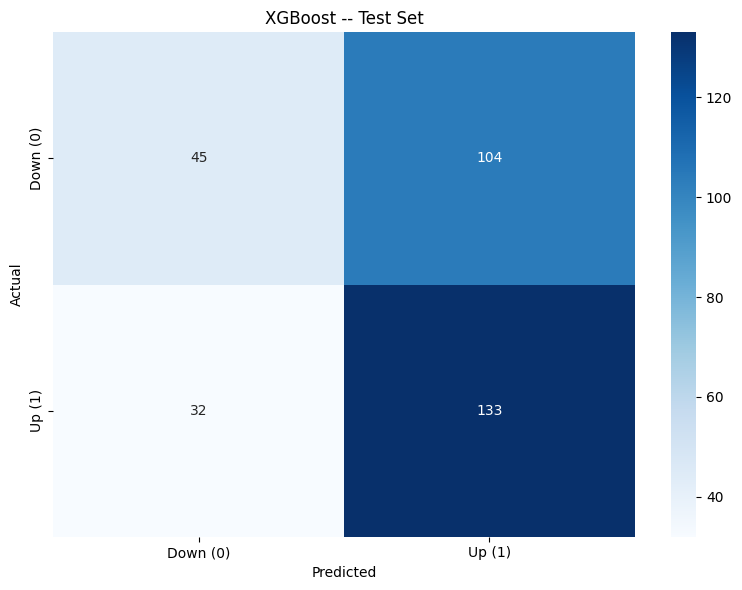


Confusion Matrix Breakdown:
  True Negatives (predicted down, was down):  45
  False Positives (predicted up, was down):   104
  False Negatives (predicted down, was up):   32
  True Positives (predicted up, was up):      133
✅ Feature importance plot saved to d:\machine learning\Machine Learning Project\stock_ml_project\outputs/xgboost_feature_importance.png


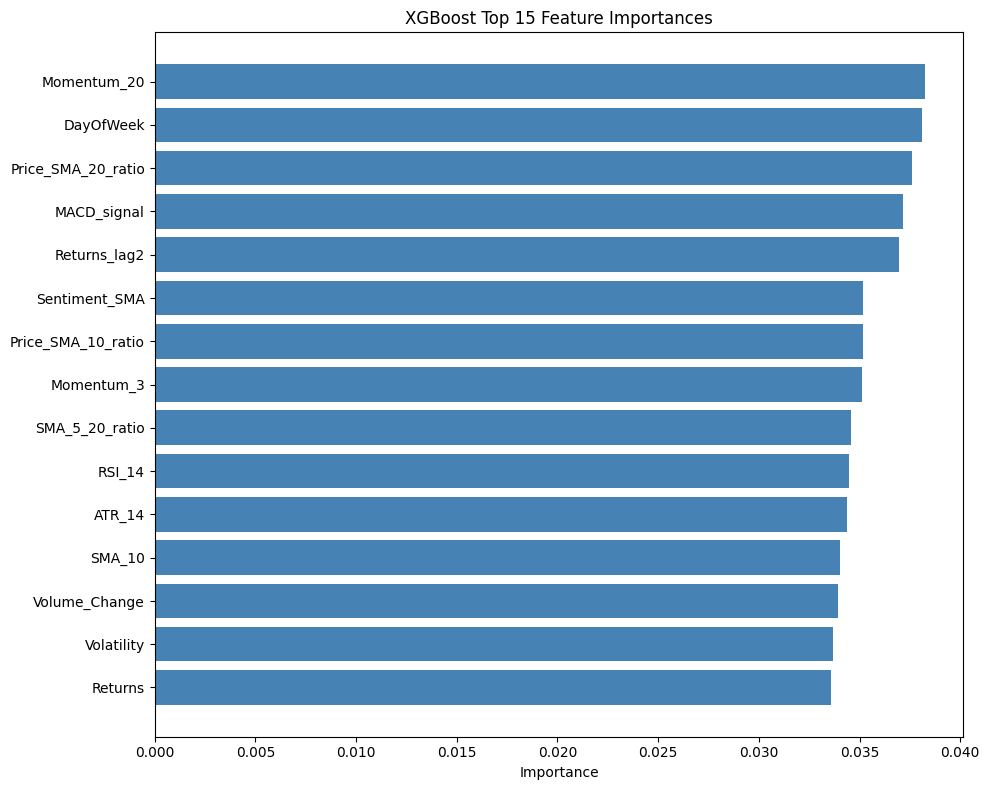


Top 15 Features:
  Momentum_20: 0.0382
  DayOfWeek: 0.0381
  Price_SMA_20_ratio: 0.0376
  MACD_signal: 0.0372
  Returns_lag2: 0.0370
  Sentiment_SMA: 0.0352
  Price_SMA_10_ratio: 0.0352
  Momentum_3: 0.0351
  SMA_5_20_ratio: 0.0346
  RSI_14: 0.0345
  ATR_14: 0.0344
  SMA_10: 0.0340
  Volume_Change: 0.0339
  Volatility: 0.0337
  Returns: 0.0336


In [6]:
xgb_model = train_xgboost(X_train, y_train)
xgb_metrics, xgb_pred = evaluate_xgboost_model(xgb_model, X_train, y_train, X_test, y_test)

plot_xgb_confusion_matrix(y_test, xgb_pred, title='XGBoost -- Test Set')
plot_xgb_feature_importance(xgb_model, feature_names, top_n=15)

## Step 5: Support Vector Machine (SVM)

RBF-kernel SVM with `StandardScaler` feature normalisation. Low regularisation (`C=0.5`) keeps a wide margin — important for noisy financial data. `gamma='scale'` normalises by `n_features * X.var()`.

> SVM can be slow on large datasets. For 5 years of data (~1 250 train samples) it typically finishes in under a minute.


TRAINING SVM MODEL
Parameters: {'kernel': 'rbf', 'C': 0.5, 'gamma': 'scale', 'class_weight': 'balanced', 'probability': True, 'random_state': 42}

Training model...
✅ Model training complete!

SVM MODEL EVALUATION

TRAINING SET PERFORMANCE:
  Accuracy:  0.6238
  Precision: 0.6385
  Recall:    0.6702
  F1 Score:  0.6539

TEST SET PERFORMANCE:
  Accuracy:  0.4968
  Precision: 0.5169
  Recall:    0.6485
  F1 Score:  0.5753

⚠️  Warning: Possible overfitting detected!
   Train accuracy is 12.70% higher than test

DETAILED CLASSIFICATION REPORT (Test Set):
              precision    recall  f1-score   support

    Down (0)       0.46      0.33      0.38       149
      Up (1)       0.52      0.65      0.58       165

    accuracy                           0.50       314
   macro avg       0.49      0.49      0.48       314
weighted avg       0.49      0.50      0.48       314



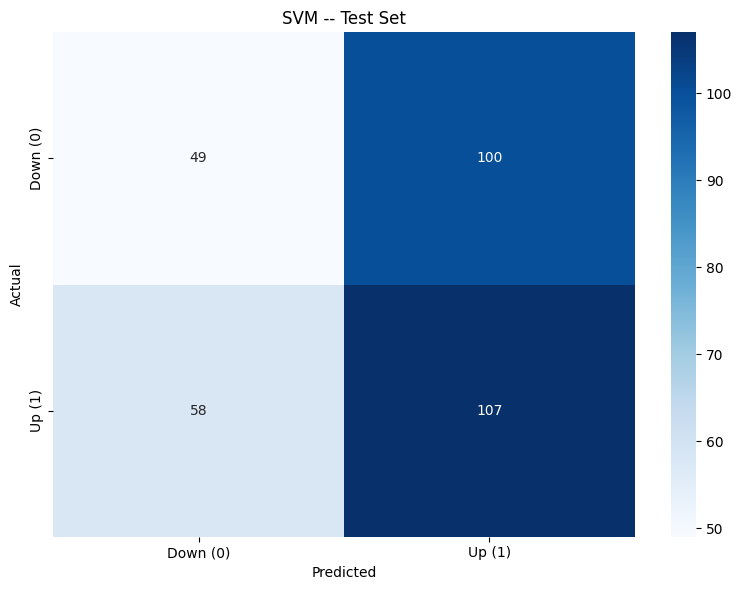


Confusion Matrix Breakdown:
  True Negatives (predicted down, was down):  49
  False Positives (predicted up, was down):   100
  False Negatives (predicted down, was up):   58
  True Positives (predicted up, was up):      107


In [7]:
svm_model, svm_scaler = train_svm(X_train, y_train)
svm_metrics = evaluate_svm(svm_model, svm_scaler, X_train, y_train, X_test, y_test)

svm_pred = svm_model.predict(svm_scaler.transform(X_test))
plot_confusion_matrix(y_test, svm_pred, title='SVM -- Test Set')

## Step 6: Three-Model Comparison

Trains all three models on the same chronological 80/20 split and generates:
- ROC curves (AUC comparison)
- Metrics bar chart (accuracy, precision, recall, F1)
- Feature importance comparison (RF vs XGBoost)

Results are saved to `outputs/comparison_results.csv`.


               MODEL COMPARISON PIPELINE

Stock: AAPL

1. Loading stock data...
✅ Loaded 1587 rows from d:\machine learning\Machine Learning Project\stock_ml_project\data\raw\AAPL_raw.csv
2. Preprocessing data...

PREPROCESSING PIPELINE

Step 1: Cleaning data...

Step 2: Handling missing values...
Dropped 0 rows with missing values

Step 3: Validating data...
✅ Data validation passed

Preprocessing complete: 1587 rows

3. Engineering features...

FEATURE ENGINEERING PIPELINE

✅ Added 'Returns' feature
✅ Added 'SMA_5' feature
✅ Added 'SMA_10' feature
✅ Added 'SMA_20' feature
✅ Added 'Volatility' feature (window=20)
✅ Added 'Momentum_3' feature
✅ Added 'Momentum_5' feature
✅ Added 'Momentum_10' feature
✅ Added 'Momentum_20' feature
✅ Added 'Volume_Change' feature
✅ Added 'HL_Spread' feature
✅ Added 'Returns_lag1' feature
✅ Added 'Returns_lag2' feature
✅ Added 'Returns_lag3' feature
✅ Added 'Volume_Ratio' feature (window=20)
✅ Added 'DayOfWeek' feature
✅ Added 'RSI_14' feature (window=14

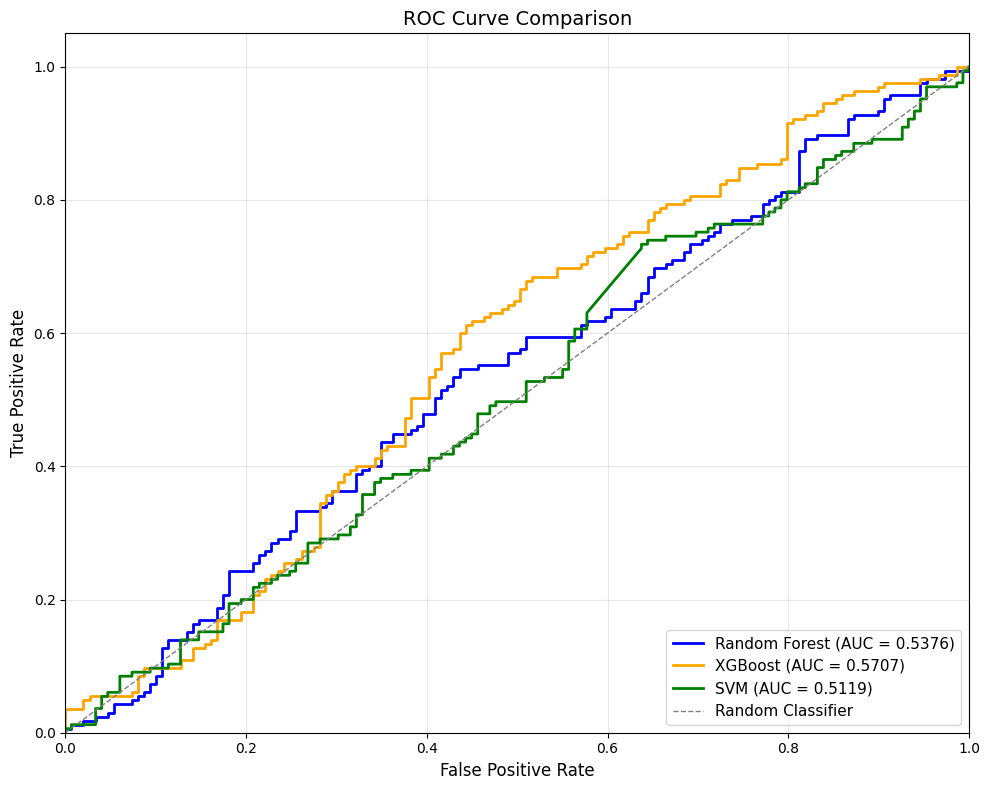


Plotting metrics comparison...
[OK] Metrics comparison saved to d:\machine learning\Machine Learning Project\stock_ml_project\outputs/metrics_comparison.png


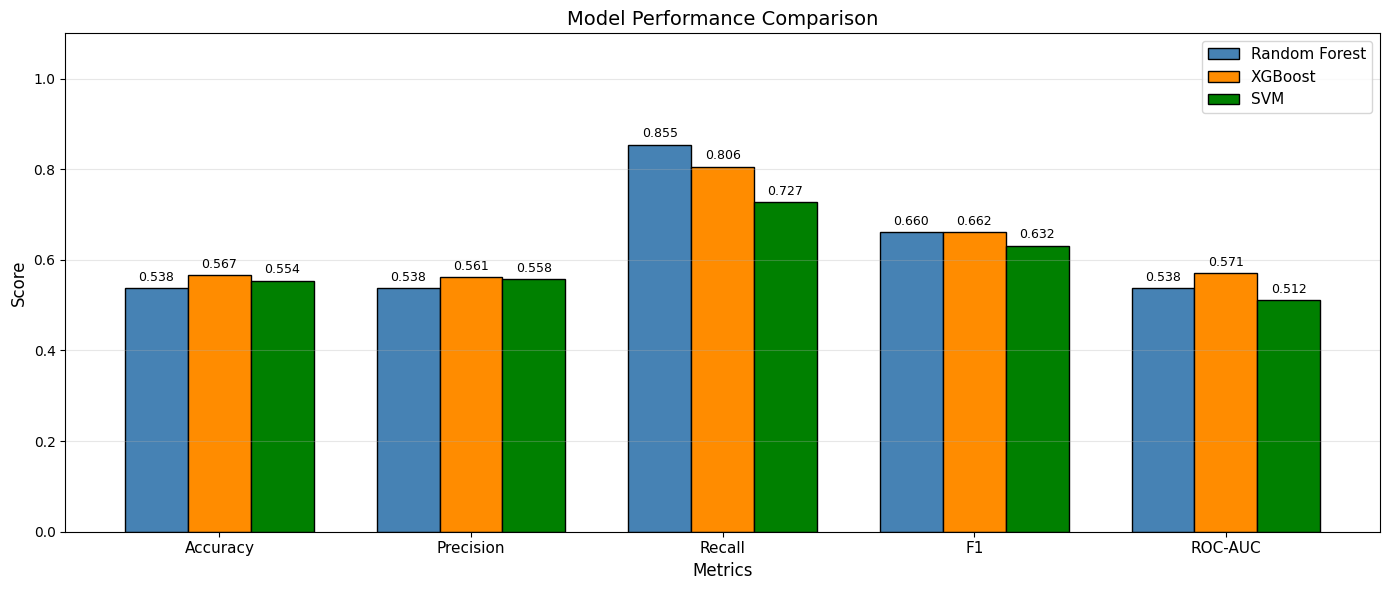


Plotting feature importance comparison...
[OK] Feature importance comparison saved to d:\machine learning\Machine Learning Project\stock_ml_project\outputs/feature_importance_comparison.png


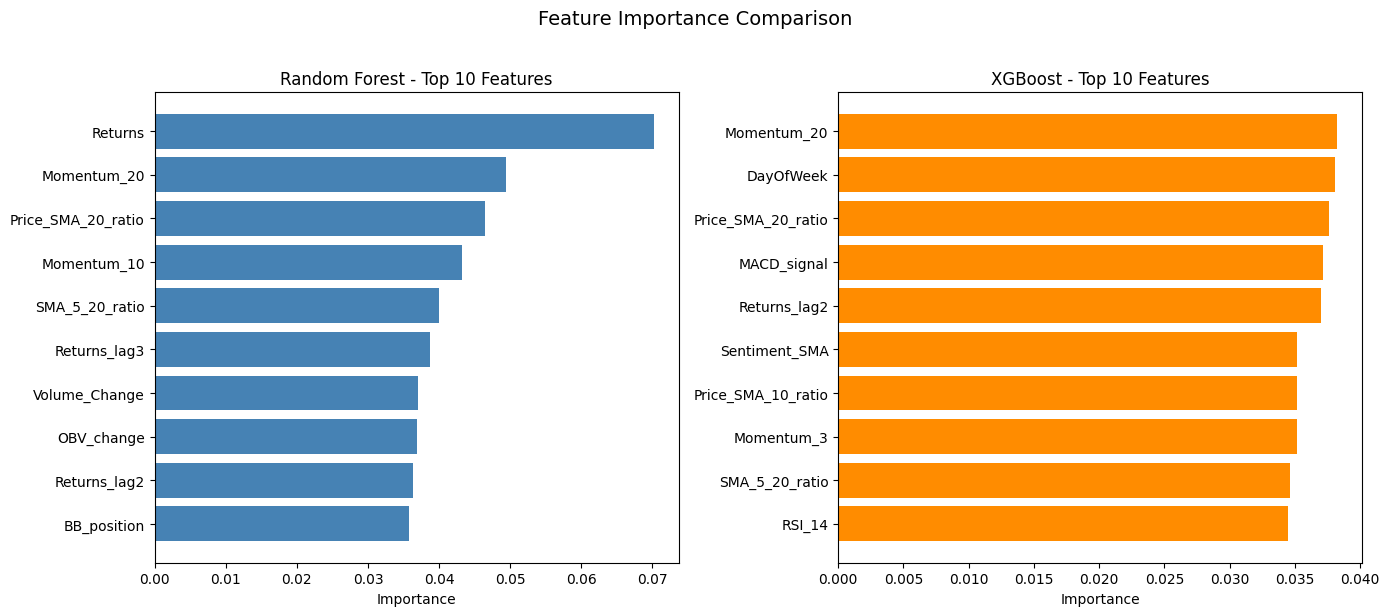


[OK] Results saved to d:\machine learning\Machine Learning Project\stock_ml_project\outputs\comparison_results.csv

                    COMPARISON COMPLETE!


In [8]:
comparison_results = run_full_comparison(ticker=TICKER)

## Step 7: Walk-Forward Backtesting

Simulates real deployment: train on all past data, predict the next window, expand the window, repeat across 10 folds (`TimeSeriesSplit`).

Earlier folds have less training data so accuracy is typically lower than the held-out test set. The last 5 folds (most recent market regime) are most informative.


                    WALK-FORWARD VALIDATION
Number of splits: 10
Total samples: 1566

Fold 1/10
Training samples: 146
Testing samples: 142

TRAINING RANDOM FOREST MODEL
Parameters: {'n_estimators': 300, 'max_depth': 4, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'random_state': 42, 'n_jobs': 1}
✅ Model training complete!
Accuracy: 0.4507

Fold 2/10
Training samples: 288
Testing samples: 142

TRAINING RANDOM FOREST MODEL
Parameters: {'n_estimators': 300, 'max_depth': 4, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'random_state': 42, 'n_jobs': 1}
✅ Model training complete!
Accuracy: 0.4718

Fold 3/10
Training samples: 430
Testing samples: 142

TRAINING RANDOM FOREST MODEL
Parameters: {'n_estimators': 300, 'max_depth': 4, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'random_state': 42, 'n_jobs': 1}
✅ Model training complete!
Accuracy: 0.5282

Fold 4/10
Training samples: 572
Testing samples: 142

TRAININ

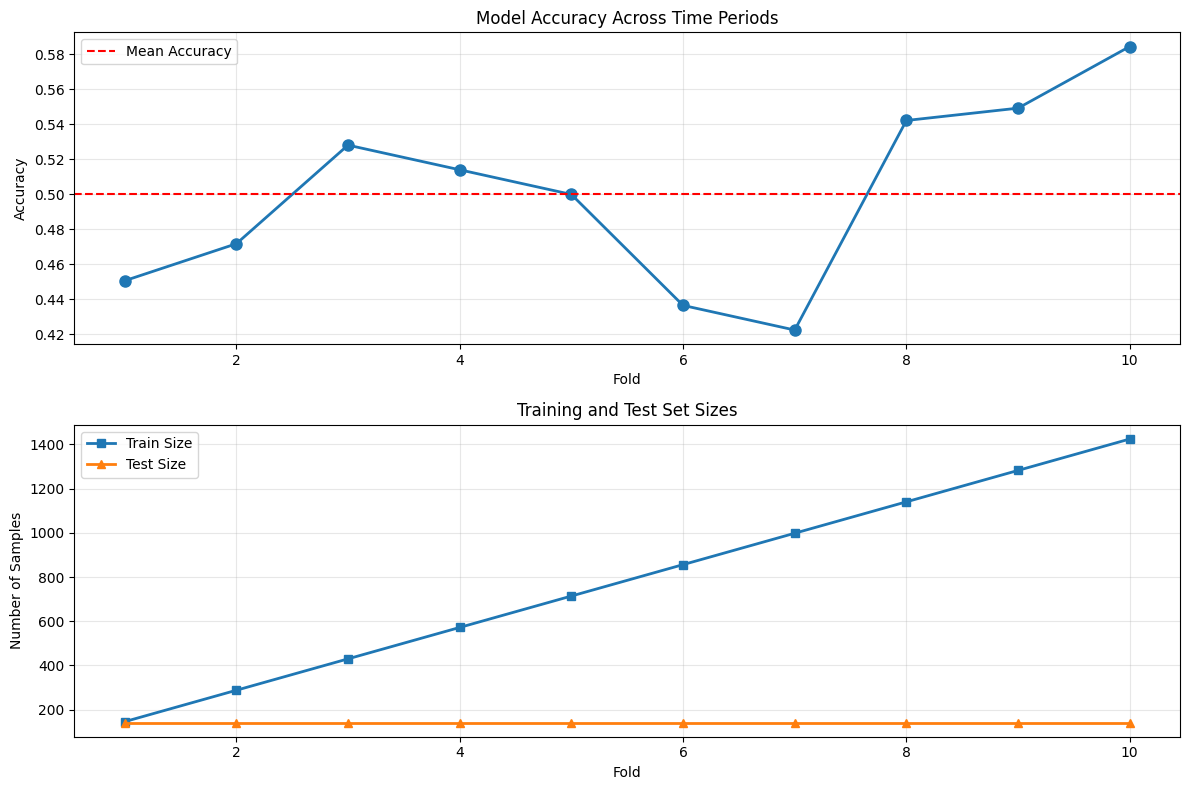


Walk-forward summary (RF, 10 folds):
  Mean accuracy: 0.5000
  Std accuracy:  0.0533
  Min / Max:     0.4225 / 0.5845


In [9]:
backtest_results = walk_forward_validation(X, y, feature_names, n_splits=config.N_SPLITS)
plot_backtest_results(backtest_results)

print(f'\nWalk-forward summary (RF, {config.N_SPLITS} folds):')
print(f'  Mean accuracy: {backtest_results["accuracy"].mean():.4f}')
print(f'  Std accuracy:  {backtest_results["accuracy"].std():.4f}')
print(f'  Min / Max:     {backtest_results["accuracy"].min():.4f} / {backtest_results["accuracy"].max():.4f}')

## Results Summary

Side-by-side metrics for all three models on the held-out test set.

In [10]:
import pandas as pd

summary = pd.DataFrame([
    {
        'Model': 'Random Forest',
        'Test Accuracy': rf_metrics['test_accuracy'],
        'Test Precision': rf_metrics['test_precision'],
        'Test Recall': rf_metrics['test_recall'],
        'Test F1': rf_metrics['test_f1'],
        'Train Accuracy': rf_metrics['train_accuracy'],
    },
    {
        'Model': 'XGBoost',
        'Test Accuracy': xgb_metrics['accuracy'],
        'Test Precision': xgb_metrics['precision'],
        'Test Recall': xgb_metrics['recall'],
        'Test F1': xgb_metrics['f1'],
        'Train Accuracy': xgb_metrics['train_accuracy'],
    },
    {
        'Model': 'SVM',
        'Test Accuracy': svm_metrics['test_accuracy'],
        'Test Precision': svm_metrics['test_precision'],
        'Test Recall': svm_metrics['test_recall'],
        'Test F1': svm_metrics['test_f1'],
        'Train Accuracy': svm_metrics['train_accuracy'],
    },
])

summary = summary.set_index('Model')
print(summary.to_string(float_format='{:.4f}'.format))
print(f'\nWalk-forward mean accuracy (RF): {backtest_results["accuracy"].mean():.4f}')

               Test Accuracy  Test Precision  Test Recall  Test F1  Train Accuracy
Model                                                                             
Random Forest         0.5382          0.5382       0.8545   0.6604          0.6494
XGBoost               0.5669          0.5612       0.8061   0.6617          0.8155
SVM                   0.4968          0.5169       0.6485   0.5753          0.6238

Walk-forward mean accuracy (RF): 0.5000


---
## Optional: Full Single-Stock Pipeline

Runs data collection, preprocessing, feature engineering, RF training, baseline comparison, and backtesting in one call. Useful as a quick end-to-end smoke test.

In [ ]:
# Run the complete pipeline for a single stock
# results = run_complete_pipeline('AAPL')
#
# if results:
#     acc = results['model_results']['metrics']['test_accuracy']
#     print(f'Test Accuracy: {acc:.2%}')

## Optional: Multi-Stock Analysis

Runs the full pipeline for every ticker in `config.TICKERS`. Takes 3-5 minutes per stock.

In [ ]:
# Uncomment to run for all tickers in config.TICKERS
# results_all = run_multiple_stocks()
#
# if results_all:
#     for ticker, r in results_all.items():
#         acc = r['model_results']['metrics']['test_accuracy']
#         bt_acc = r['backtest_results']['accuracy'].mean()
#         print(f'{ticker:6s}  test={acc:.2%}  backtest={bt_acc:.2%}')